In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from matplotlib.lines import Line2D

In [2]:
def solve_sme(rho0,time,Omega,gamma1,Gamma_m,ntraj,seed):

    # driving Hamiltonian
    H = 1/2 * Omega * qt.sigmax()

    # T1 decay, unmonitored
    c_ops = np.sqrt(gamma1) * qt.sigmam()

    # Monitored channel as done in Gamebtta et., al (2008) but simplified...
    ''' we neglect dephasing mechanisms for now --> will add later!'''
    sc_ops = [np.sqrt(Gamma_m) * qt.sigmaz()]

    
    result = qt.smesolve(
        H,
        rho0,
        time,
        c_ops,
        sc_ops,
        e_ops=[rho0],
        ntraj=ntraj,
        seeds=seed,
        options={"keep_runs_results": True,"store_measurement": True,"progress_bar": "",},)

    pee_runs = np.array(result.runs_expect[0])

    return pee_runs

## Setup our initial conditions

In [3]:
# start in excited state rho(0) = |e><e| or psi(0) = |e>
pee_op = qt.basis(2, 0) * qt.basis(2, 0).dag()

# Initial state: excited state |e><e|
rho0 = pee_op

# Time grid
time = np.linspace(0.0, 20.0, 1000)

## Solve Stochastic SME with no drive on our qubit ($\Omega_r = 0$)

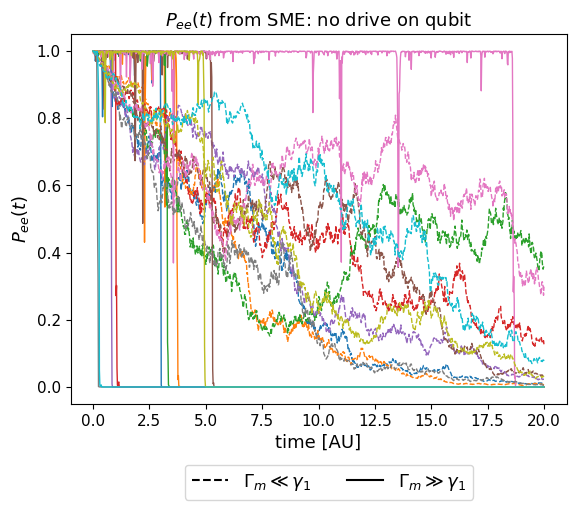

In [4]:
fig,ax = plt.subplots()
colors = plt.get_cmap("tab10").colors

# set Hamiltonian/Master Equation parameters
Omega = 0
gamma1 = 0.1
Gamma_m_low = 0.01 # expect no zeno
Gamma_m_high = 10 # expect zeno 
ntraj = 10
seed = 7

# solve our SMEs
pee_no_drive_large_gamma1 = solve_sme(rho0,time,Omega,gamma1,Gamma_m_low,ntraj,seed) # expect no zeno and typical relaxation
pee_no_drive_large_Gamma_m = solve_sme(rho0,time,Omega,gamma1,Gamma_m_high,ntraj,seed) # expect zeno

col_count = 0 
## iteratively plot P_ee(t) for each quantum trajectory 
for i,j in zip(pee_no_drive_large_gamma1,pee_no_drive_large_Gamma_m):
    c = colors[col_count]
    col_count += 1
    
    plt.plot(time, i, lw=1,color = c,linestyle = 'dashed')
    plt.plot(time, j, lw=1,color = c)

legend_elements = [
    Line2D([0], [0], color='black',
           linestyle='dashed', markersize=8, label=r'$\Gamma_m \ll \gamma_1$'),
    Line2D([0], [0], color='black',
           linestyle='-', markersize=8, label=r'$\Gamma_m \gg \gamma_1$'),
]

ax.legend(handles=legend_elements,fontsize = 13,ncol = 2,bbox_to_anchor = (.83,-.14))

plt.ylabel(r"$P_{ee}(t)$",fontsize = 13)
plt.xlabel("time [AU]",fontsize = 13)
ax.tick_params("x",labelsize = 11)
ax.tick_params("y",labelsize = 11)
plt.title(r"$P_{ee}(t)$ from SME: no drive on qubit",fontsize = 13)
plt.savefig("Figures/qutip-not-driven-qubit.pdf",bbox_inches = "tight")

## Solve Stochastic SME with a driven qubit

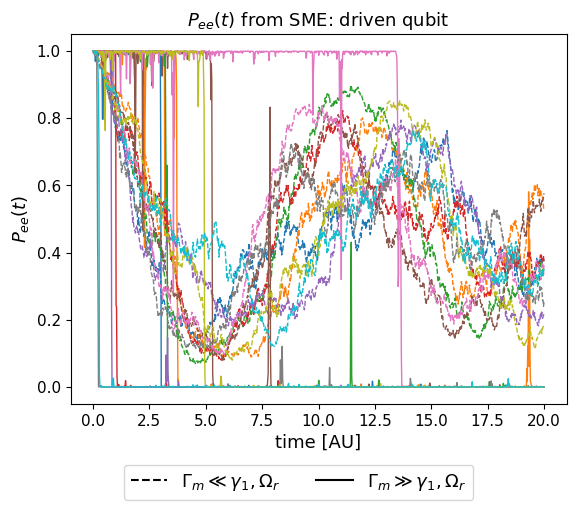

In [5]:
fig,ax = plt.subplots()

# set Hamiltonian/Master Equation parameters
Omega = 0.5
gamma1 = 0.1
Gamma_m_low = 0.01 # expect no zeno
Gamma_m_high = 10 # expect zeno 
ntraj = 10
seed = 7

# solve our SMEs
pee_drive_large_gamma1 = solve_sme(rho0,time,Omega,gamma1,Gamma_m_low,ntraj,seed) # expect no zeno and typical Rabi oscillations
pee_drive_large_Gamma_m = solve_sme(rho0,time,Omega,gamma1,Gamma_m_high,ntraj,seed) # expect zeno

col_count = 0 

## iteratively plot P_ee(t) for each quantum trajectory 
for i,j in zip(pee_drive_large_gamma1,pee_drive_large_Gamma_m):
    c = colors[col_count]
    col_count += 1
    
    plt.plot(time, i, lw=1,color = c,linestyle = 'dashed')
    plt.plot(time, j, lw=1,color = c)

legend_elements = [
    Line2D([0], [0], color='black',
           linestyle='dashed', markersize=8, label=r'$\Gamma_m \ll \gamma_1 , \Omega_r$'),
    Line2D([0], [0], color='black',
           linestyle='-', markersize=8, label=r'$\Gamma_m \gg \gamma_1,  \Omega_r$'),
]

ax.legend(handles=legend_elements,fontsize = 13,ncol = 2,bbox_to_anchor = (.83,-.14))

plt.ylabel(r"$P_{ee}(t)$",fontsize = 13)
plt.xlabel("time [AU]",fontsize = 13)
ax.tick_params("x",labelsize = 11)
ax.tick_params("y",labelsize = 11)
plt.title(r"$P_{ee}(t)$ from SME: driven qubit",fontsize = 13)
plt.savefig("Figures/qutip-driven-qubit.pdf",bbox_inches = "tight")